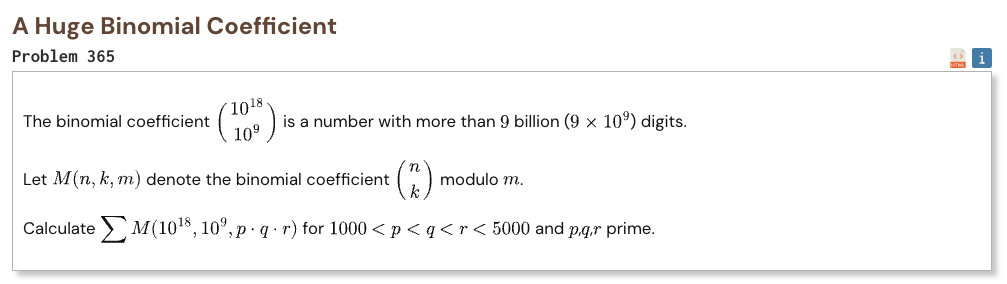

## Initial approach

* compute the binomial value modulo each prime separately
* Lucas theorem reduces the huge binomial into small digit-level binomials
* precompute factorials modulo each prime for fast small binomial values
* for every prime triple, combine the three residues with CRT
* add the combined value to the total
* only primes between 1000 and 5000 are needed

In [1]:
import math

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            is_prime[p * p:limit + 1:p] = b"\x00" * (((limit - p * p) // p) + 1)

    return [i for i in range(limit + 1) if is_prime[i]]

def prepare_factorials(p):
    fact = [1] * p

    for i in range(1, p):
        fact[i] = fact[i - 1] * i % p

    inv_fact = [1] * p
    inv_fact[p - 1] = pow(fact[p - 1], p - 2, p)

    for i in range(p - 1, 0, -1):
        inv_fact[i - 1] = inv_fact[i] * i % p

    return fact, inv_fact

def small_comb(n, k, p, fact, inv_fact):
    if k < 0 or k > n:
        return 0

    return fact[n] * inv_fact[k] % p * inv_fact[n - k] % p

def lucas(n, k, p):
    fact, inv_fact = prepare_factorials(p)
    result = 1

    while n or k:
        ni = n % p
        ki = k % p

        if ki > ni:
            return 0

        result = result * small_comb(ni, ki, p, fact, inv_fact) % p

        n //= p
        k //= p

    return result

def crt3(a, p, b, q, c, r):
    mod = p * q * r

    m1 = q * r
    m2 = p * r
    m3 = p * q

    result = 0
    result += a * m1 * pow(m1, -1, p)
    result += b * m2 * pow(m2, -1, q)
    result += c * m3 * pow(m3, -1, r)

    return result % mod

def solve():
    n = 10 ** 18
    k = 10 ** 9

    primes = [p for p in prime_sieve(5000) if p > 1000]
    residues = {p: lucas(n, k, p) for p in primes}

    total = 0

    for i in range(len(primes)):
        p = primes[i]

        for j in range(i + 1, len(primes)):
            q = primes[j]

            for k_index in range(j + 1, len(primes)):
                r = primes[k_index]

                total += crt3(
                    residues[p], p,
                    residues[q], q,
                    residues[r], r
                )

    return total

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 162619462356610313
CPU times: user 20 s, sys: 43 ms, total: 20 s
Wall time: 20.1 s
